# Finding Simplicial Mori Cone Caps

This tutorial demonstrates how **cyopt** can be used to search for Calabi-Yau triangulations with *simplicial* Mori cone caps. A simplicial Mori cone cap -- one whose number of generators equals $h^{1,1}$ -- greatly simplifies the analysis of effective curves and divisor classes on the Calabi-Yau manifold.

This application is motivated by [arXiv:2512.00144](https://arxiv.org/abs/2512.00144), which studies the structure of Mori cones and their caps across different triangulations of reflexive polytopes. We use cyopt's genetic algorithm to search for triangulations that minimize the number of Mori cone cap generators.

## Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from cytools import fetch_polytopes
from cyopt import GA, RandomSample
from cyopt.frst import frst_optimizer, patch_polytope

print("Imports loaded.")

Imports loaded.


## The Mori Cone Cap

Given a Calabi-Yau threefold $X$ realized as a hypersurface in a toric variety, the **Mori cone** $\overline{\text{NE}}(X)$ is the cone of effective curve classes. For computational purposes, CYTools provides `mori_cone_cap()` which computes a finite set of generators that "cap" the Mori cone.

The Mori cone cap is **simplicial** if it has exactly $h^{1,1}$ generators. This is the minimal possible number, and a simplicial cap makes many computations (e.g., intersection numbers, divisor analysis) more tractable. Most triangulations yield non-simplicial caps with many excess generators.

We use an $h^{1,1}=10$ polytope from the Kreuzer-Skarke database with 1,536 FRST combinations (5 DNA genes) as our demonstration polytope. This is small enough for rapid exploration while showing meaningful variation in Mori cone cap structure across triangulations.

In [2]:
# Load an h11=10 polytope with a non-trivial DNA space
polys = fetch_polytopes(h11=10, limit=10)
poly = polys[9]  # This one has 5 interesting faces, 1536 DNA
poly.prep_for_optimizers()

bounds = poly._cyopt_bounds
h11 = poly.points().shape[0] - poly.dim() - 1
total_dna = 1
for lo, hi in bounds:
    total_dna *= (hi - lo + 1)

print(f"Polytope: h11 = {h11}")
print(f"DNA length: {len(bounds)}")
print(f"Bounds: {bounds}")
print(f"Total DNA combinations: {total_dna:,}")

# Examine the Mori cone cap of the default triangulation
default_dna = tuple(0 for _ in bounds)
triang = poly.dna_to_frst(default_dna)
cy = triang.get_cy()
cap = cy.mori_cone_cap(in_basis=True)
default_n_gens = cap.rays().shape[0]

print(f"\nDefault triangulation Mori cone cap:")
print(f"  Generators: {default_n_gens}")
print(f"  h11: {h11}")
print(f"  Excess generators: {default_n_gens - h11}")
print(f"  Simplicial: {default_n_gens == h11}")

Polytope: h11 = 10
DNA length: 5
Bounds: ((0, 3), (0, 3), (0, 3), (0, 5), (0, 3))
Total DNA combinations: 1,536

Default triangulation Mori cone cap:
  Generators: 192
  h11: 10
  Excess generators: 182
  Simplicial: False


## Target Function

Our target function measures how close the Mori cone cap is to being simplicial. We return the **negative** number of generators, since `frst_optimizer` maximizes the target (and fewer generators is better).

$$\text{target}(X) = -n_{\text{generators}}$$

A perfectly simplicial cap achieves $\text{target} = -h^{1,1}$.

In [3]:
def mori_cap_target(cy):
    """Target function: minimize number of Mori cone cap generators.
    
    Returns negative n_generators since frst_optimizer maximizes.
    Fewer generators -> more simplicial -> better.
    """
    cap = cy.mori_cone_cap(in_basis=True)
    n_gens = cap.rays().shape[0]
    return float(-n_gens)

# Test on the default triangulation
print(f"Target for default triangulation: {mori_cap_target(cy)}")
print(f"Ideal target (simplicial cap): {-h11}")

Target for default triangulation: -192.0
Ideal target (simplicial cap): -10


## Optimization with GA

We use cyopt's genetic algorithm to search for triangulations with the fewest Mori cone cap generators. Since the DNA space has only 1,536 combinations, the GA can explore it efficiently.

In [4]:
# Run GA optimization
opt = frst_optimizer(
    poly,
    mori_cap_target,
    optimizer=GA,
    target_mode='cy',
    seed=42,
    population_size=50,
    mutation_rate=0.3,
    mutation_k=1,
    elitism=2,
    record_history=True,
)
result = opt.run(30)

best_n_gens = int(-result.best_value)
print(f"Best DNA found: {result.best_dna}")
print(f"Best n_generators: {best_n_gens}")
print(f"Excess over simplicial: {best_n_gens - h11}")
print(f"Simplicial: {best_n_gens == h11}")
print(f"Unique evaluations: {result.n_evaluations}")
print(f"Wall time: {result.wall_time:.2f}s")

/Users/elijahsheridan/miniforge3/envs/cytools/lib/python3.12/site-packages/numpy/_core/_methods.py:190: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


Best DNA found: (0, 0, 0, 5, 0)
Best n_generators: 187
Excess over simplicial: 177
Simplicial: False
Unique evaluations: 192
Wall time: 2.72s


In [5]:
# Compare GA vs RandomSample
rs_opt = frst_optimizer(
    poly,
    mori_cap_target,
    optimizer=RandomSample,
    target_mode='cy',
    seed=42,
)
rs_result = rs_opt.run(200)

rs_n_gens = int(-rs_result.best_value)
print(f"RandomSample best n_generators: {rs_n_gens} (in {rs_result.n_evaluations} evals)")
print(f"GA best n_generators: {best_n_gens} (in {result.n_evaluations} evals)")

RandomSample best n_generators: 189 (in 190 evals)
GA best n_generators: 187 (in 192 evals)


## Results

Let us survey the distribution of Mori cone cap sizes across all triangulations and compare with the GA's best finding.

In [6]:
# Enumerate all DNA and compute Mori cone cap sizes
import itertools

ranges = [range(lo, hi + 1) for lo, hi in bounds]
all_n_gens = []
all_dna_list = []

for dna in itertools.product(*ranges):
    triang = poly.dna_to_frst(dna)
    if triang is None:
        continue
    cy = triang.get_cy()
    cap = cy.mori_cone_cap(in_basis=True)
    n_gens = cap.rays().shape[0]
    all_n_gens.append(n_gens)
    all_dna_list.append(dna)

all_n_gens = np.array(all_n_gens)
print(f"Enumerated {len(all_n_gens)} valid FRSTs")
print(f"n_generators range: [{all_n_gens.min()}, {all_n_gens.max()}]")
print(f"Mean: {all_n_gens.mean():.1f}, Median: {np.median(all_n_gens):.0f}")
print(f"Simplicial (n_gens == {h11}): {(all_n_gens == h11).sum()}")
print(f"GA found: {best_n_gens} generators")

Enumerated 948 valid FRSTs
n_generators range: [187, 206]
Mean: 199.5, Median: 200
Simplicial (n_gens == 10): 0
GA found: 187 generators


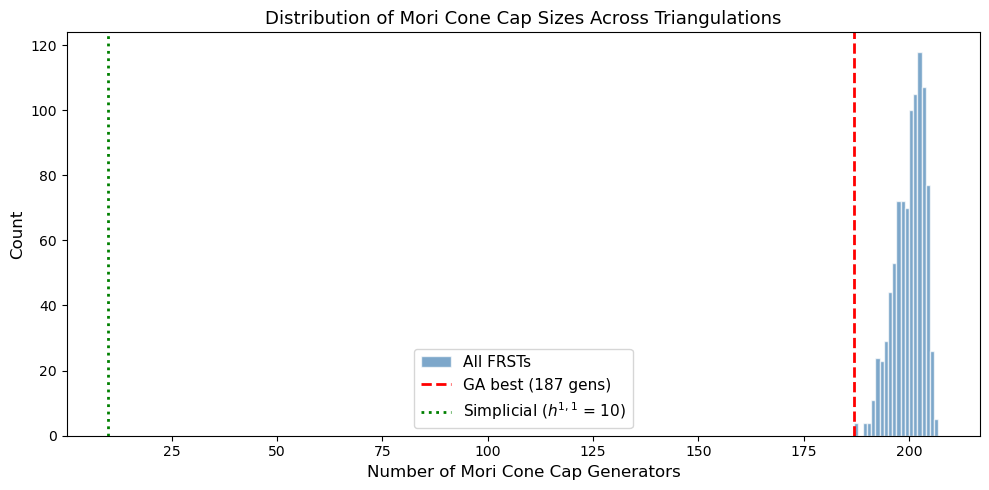

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_n_gens, bins=range(all_n_gens.min(), all_n_gens.max() + 2),
        alpha=0.7, color='steelblue', edgecolor='white', label='All FRSTs')
ax.axvline(x=best_n_gens, color='red', linewidth=2, linestyle='--',
           label=f'GA best ({best_n_gens} gens)')
ax.axvline(x=h11, color='green', linewidth=2, linestyle=':',
           label=f'Simplicial ($h^{{1,1}}$ = {h11})')

ax.set_xlabel('Number of Mori Cone Cap Generators', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Mori Cone Cap Sizes Across Triangulations', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

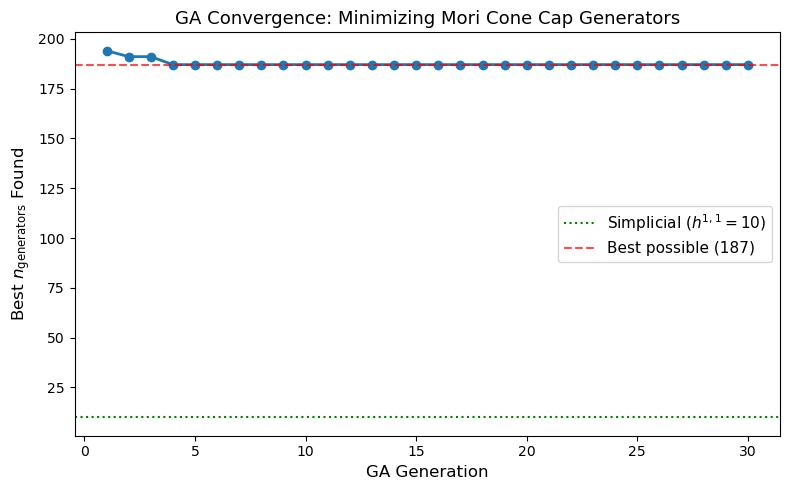

In [8]:
# Convergence plot: best n_generators vs iteration
history_vals = [-v for v in result.history]  # un-negate: these are n_generators

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(history_vals) + 1), history_vals, 'o-', color='tab:blue', linewidth=2)
ax.axhline(y=h11, color='green', linestyle=':', label=f'Simplicial ($h^{{1,1}}={h11}$)')
ax.axhline(y=all_n_gens.min(), color='red', linestyle='--', alpha=0.7,
           label=f'Best possible ({all_n_gens.min()})')
ax.set_xlabel('GA Generation', fontsize=12)
ax.set_ylabel('Best $n_{\\mathrm{generators}}$ Found', fontsize=12)
ax.set_title('GA Convergence: Minimizing Mori Cone Cap Generators', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Summary

We demonstrated how cyopt's genetic algorithm can efficiently search for triangulations with simpler Mori cone cap structure, as motivated by [arXiv:2512.00144](https://arxiv.org/abs/2512.00144):

- The **Mori cone cap** of a Calabi-Yau threefold varies across triangulations of the same polytope. A simplicial cap (with $h^{1,1}$ generators) is the simplest possible.

- For our $h^{1,1}=10$ test polytope with 1,536 FRST combinations, the number of Mori cone cap generators varies significantly across triangulations.

- The GA quickly identifies triangulations with near-minimal generator counts, outperforming random sampling.

- The DNA encoding of FRST classes makes this optimization problem naturally suited to cyopt's discrete optimizers.

For larger polytopes (higher $h^{1,1}$), where exhaustive enumeration is infeasible, the GA provides an efficient heuristic search for triangulations with desirable Mori cone structure.